Nobre : juan sebastian poveda forero

<div style="background:#022F35;padding:32px 34px;border-radius:16px;color:#fff;font-family:Calibri,Corbel,sans-serif">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">VISUALIZACIÓN DE DATOS &nbsp;·&nbsp; UNIVERSIDAD EAN</div>
<h1 style="color:#fff;margin:10px 0 8px 0;font-size:30px">🚲 Del dato a la decisión</h1>
<div style="color:#CADCFC;font-size:15px;line-height:1.5">Cargue, limpieza y análisis exploratorio, guiados por gráficos — el camino directo al Hito 1 del proyecto de semestre.</div>
</div>

### 🤔 Qué es este cuaderno y qué no es

Este **no** es un cuaderno de programación. El código que van a encontrar es corto a propósito: lo que importa no es escribirlo, es **mirar lo que produce y decidir algo con eso**. Si en algún punto se preguntan "¿por qué esta línea?", la respuesta casi siempre es "para poder ver el gráfico de abajo", no "porque hay que aprenderse esto de memoria".

El cuaderno los acompaña por tres etapas del ciclo de vida de los datos que ya vieron en clase:

| Etapa | Lo que hacemos aquí |
|---|---|
| 2 · Recolección | Cargar los datos y mirarlos con desconfianza profesional |
| 3 · Limpieza | Usar gráficos para encontrar lo que está mal, no para decorar |
| 4 · Análisis exploratorio (EDA) | Hacer muchas preguntas rápidas con gráficos, antes de sacar conclusiones |

Vamos a trabajar con un caso inventado pero realista: los viajes de un sistema de bicicletas compartidas. Primero con una tabla pequeñita, de solo 12 viajes, para poder revisarla con calma, casi fila por fila. Después con una versión mucho más grande —1200 viajes—, para que vean con sus propios ojos por qué, a partir de cierto tamaño, ya no alcanza con mirar uno por uno: hace falta apoyarse en resúmenes y en gráficos.

### 🧭 Cómo leer este cuaderno

No necesitan subir ningún archivo: todos los datos ya están escritos dentro del propio cuaderno. Ejecuten las celdas en orden, de arriba hacia abajo — cada una depende de las anteriores.

| Símbolo | Qué significa |
|---|---|
| ▶️ | Celda de código: ejecútenla y miren con calma qué produce |
| ✍️ | Es su turno: piensen o escriban una respuesta antes de seguir |
| 💡 | Una pista o una idea clave para no quedarse atascados |
| 🎯 | Por qué este paso importa, no solo qué hace |

En Colab: `Archivo → Subir cuaderno` o ábranlo directamente desde Drive. Para descargar su propia copia ya trabajada: `Archivo → Descargar → Descargar .ipynb`.

In [1]:
# En esta cajita de código se importan los paquetes necesarios para este cuaderno

import numpy as np                # Nos ayudará para hacer cuentas con números y generar datos al azar
import pandas as pd               # Cajita de herramientas para manejo de tablas
import matplotlib.pyplot as plt   # Sirve para dibujar gráficos desde cero
import seaborn as sns             # Otra caja de dibujo, construida encima de matplotlib, que hace gráficos más elaborados con menos líneas

sns.set_theme(style="whitegrid")  # Esta parte es solo visualización: todos los gráficos de aquí en adelante tendrán fondo blanco con líneas guía tenues
plt.rcParams["figure.dpi"] = 110  # Ayuda a tener más nitidez en las imágenes

print("Listo. pandas", pd.__version__, "| seaborn", sns.__version__)

Listo. pandas 2.2.2 | seaborn 0.13.2


<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 1 &nbsp;·&nbsp; 🔍 EL PRIMER VISTAZO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Cargue: la primera mirada honesta</h2>
</div>

Antes de graficar nada, cualquier tabla de datos merece que la miren con **desconfianza profesional**: no asumir que está bien solo porque se ve ordenada. En esta parte vamos a dejar que `pandas` y un par de gráficos hagan esa primera revisión por nosotros.

In [3]:
from io import StringIO

# StringIO hace que un texto normal se comporte, para efectos de pandas,
# exactamente como si fuera un archivo guardado en el computador.
# Por eso no vamos a subir ningún archivo: los datos ya están escritos aquí mismo, tal como llegarían en la vida real, con toda su suciedad intacta.

crudo = StringIO("""id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
1,2025-03-01,Chapinero,12,28,mensual
2,2025-03-01,CHAPINERO,8,34,ocasional
3,2025-03-02,Usaquén,15,22,mensual
4,2025-03-02,Chapinero ,-5,41,Mensual
5,2025-03-03,Teusaquillo,,29,ocasional
6,2025-03-03,Usaquén,145,31,mensual
7,03/03/2025,Chapinero,11,19,ocasional
8,2025-03-04,Teusaquillo,9,203,mensual
9,2025-03-04,Usaquén,14,27,MENSUAL
10,2025-03-05,Chapinero,10,33,ocasional
10,2025-03-05,Chapinero,10,33,ocasional
12,2025-03-06,Suba,18,,mensual
""")

viajes = pd.read_csv(crudo)
# .read_csv() lee ese texto y lo convierte en una tabla (DataFrame): cada línea se vuelve una fila,
# y cada valor separado por comas se vuelve una columna.

viajes  # al escribir solo el nombre de la tabla al final de la celda, Colab la muestra formateada, sin necesidad de un print()

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
0,1,2025-03-01,Chapinero,12.0,28.0,mensual
1,2,2025-03-01,CHAPINERO,8.0,34.0,ocasional
2,3,2025-03-02,Usaquén,15.0,22.0,mensual
3,4,2025-03-02,Chapinero,-5.0,41.0,Mensual
4,5,2025-03-03,Teusaquillo,NaN,29.0,ocasional
5,6,2025-03-03,Usaquén,145.0,31.0,mensual
6,7,03/03/2025,Chapinero,11.0,19.0,ocasional
7,8,2025-03-04,Teusaquillo,9.0,203.0,mensual
8,9,2025-03-04,Usaquén,14.0,27.0,MENSUAL
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional


### 👀 Antes de tocar el teclado, miren la tabla con calma

No hace falta saber programar para notar que algo anda mal en una tabla. Recorran columna por columna y pregúntense, en cada una: **¿este valor tiene sentido?**

Algunas pistas de qué buscar:

- En `estacion_origen`: ¿está siempre escrita igual, o hay una misma estación escrita de formas distintas (mayúsculas, espacios de más)?
- En `edad_usuario`: ¿todas las edades son razonables para una persona?
- En `duracion_min`: ¿algún número no tiene ningún sentido para la duración de un viaje?
- En `fecha`: ¿todas las filas escriben la fecha exactamente en el mismo formato?

✍️ **Sin escribir ningún código todavía:** cuenten cuántas cosas raras encuentran solo con mirar. Sigan leyendo cuando ya tengan un número y una lista en la cabeza — algunas sí se ven a simple vista, pero al menos una solo va a aparecer más adelante, con un gráfico.

**Escriban esta lista, luego la compararemos más adelante con todos los problemas encontrados**

1. estacion_origen tiene nombres escritos de forma inconsistente:

- Chapinero aparece como:
   
   - Chapinero
   - CHAPINERO

- Esto indica diferencias de mayúsculas/minúsculas.

- Teusaquillo también aparece con una posible inconsistencia ortográfica si se compara con el nombre oficial (habría que verificar si es un error o no).

2. duracion_min contiene un valor negativo:

-  -5.0 minutos.

- Una duración de viaje no puede ser negativa.

3. duracion_min tiene un valor faltante:

- NaN.

4. duracion_min contiene un valor poco razonable:

-  145.0 minutos.

- Aunque no es imposible, es un valor sospechoso para un viaje en bicicleta y debería revisarse.

5. fecha no tiene un formato consistente:

-  La mayoría usan:
  
   - 2025-03-01 (AAAA-MM-DD)

-  Una fila usa:

   - 03/03/2025 (DD/MM/AAAA)

6. edad_usuario contiene una edad imposible:

-  203 años.

7. edad_usuario tiene un valor faltante:

-  NaN.

8. tipo_usuario tiene diferencias en mayúsculas/minúsculas:

-  mensual

-  Mensual

-  MENSUAL

9. La columna id tiene un valor duplicado:

-  El id = 10 aparece dos veces.

In [4]:
print("Filas y columnas:", viajes.shape)  # .shape devuelve (cuántas filas, cuántas columnas) tiene la tabla
print()
viajes.dtypes  # .dtypes nos dice qué tipo de dato tiene cada columna: texto, número entero, decimal, fecha...

Filas y columnas: (12, 6)



,0
id,int64
fecha,object
estacion_origen,object
duracion_min,float64
edad_usuario,float64
tipo_usuario,object


`duracion_min` y `edad_usuario` deberían ser columnas numéricas, y sin embargo `pandas` no siempre las reconoce como tales cuando hay huecos o texto mezclado. Esa es la primera pista automática de que algo anda mal: **si una columna que "debería" ser numérica no aparece como tal, algo en su contenido no es un número.**

¿`fecha` aparece como fecha o como texto? ¿Por qué, si la mayoría de las filas trae un formato correcto?

**Analiza, responde y plantea una posible solución**

Mi analisis seria que aunque la  duracion_min y edad_usuario fueron reconocidas correctamente como columnas numéricas, fecha aparece como texto (object) porque los datos tienen formatos diferentes (por ejemplo, 2025-03-01 y 03/03/2025). Una posible solución es unificar el formato de todas las fechas y convertir la columna al tipo datetime para que pueda analizarse correctamente.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 2 &nbsp;·&nbsp; 🧹 LIMPIEZA</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Cada gráfico, una pista</h2>
</div>

Cada apartado de aquí en adelante repite el mismo patrón, que es literalmente la etapa 3 del ciclo hecha con gráficos: **un gráfico rápido revela un problema → deciden un tratamiento → lo aplican en una línea de código.** Estos gráficos son deliberadamente rápidos y sin estética — el modo exploratorio que ya distinguieron del comunicativo en clase.

### II.1 · Duplicados

In [5]:
# .duplicated() revisa fila por fila y marca con True las que son EXACTAMENTE iguales a otra fila
# keep=False es la clave: así vemos las DOS copias juntas, no solo la que se marca como "repetida"
viajes[viajes.duplicated(keep=False)]

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional
10,10,2025-03-05,Chapinero,10.0,33.0,ocasional


¿Cuántas filas exactamente iguales encuentran? Antes de borrar: ¿podría ser un viaje real repetido, o es imposible que dos personas distintas generen el mismo id con exactamente los mismos datos? Decidido esto, ejecuten:

In [6]:
viajes = viajes.drop_duplicates().reset_index(drop=True)
# .drop_duplicates() borra las filas repetidas, dejando solo una copia de cada una
# .reset_index(drop=True) vuelve a numerar las filas desde 0, sin dejar huecos donde se borró algo

viajes.shape  # confirmamos que ahora hay una fila menos

(11, 6)

### II.2 · Categorías inconsistentes

Un gráfico de barras de conteos por categoría muestra en un segundo si una misma categoría está escrita de varias formas — algo que una tabla no revela tan rápido, sobre todo cuando hay cientos de filas.

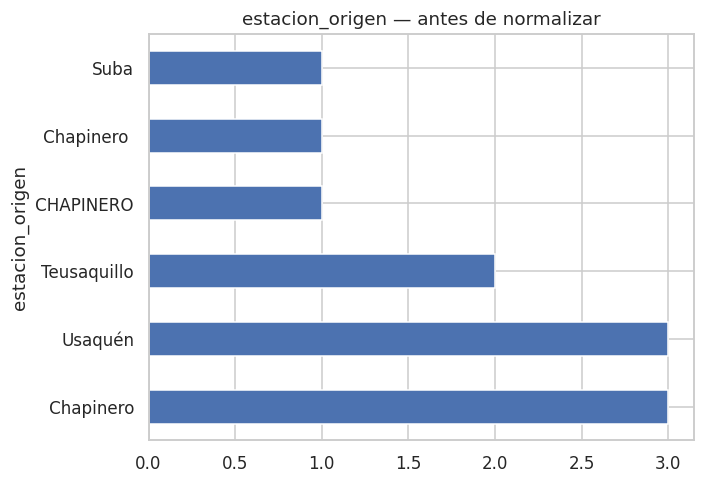

In [7]:
viajes["estacion_origen"].value_counts().plot(kind="barh")
# .value_counts() cuenta cuántas veces aparece cada valor distinto en la columna
# kind="barh" dibuja esos conteos como barras horizontales

plt.title("estacion_origen — antes de normalizar")
plt.show()  # plt.show() es la orden que finalmente despliega el dibujo en pantalla

¿Cuántas de esas barras corresponden, en realidad, a la misma estación? Repitan el gráfico para `tipo_usuario`:

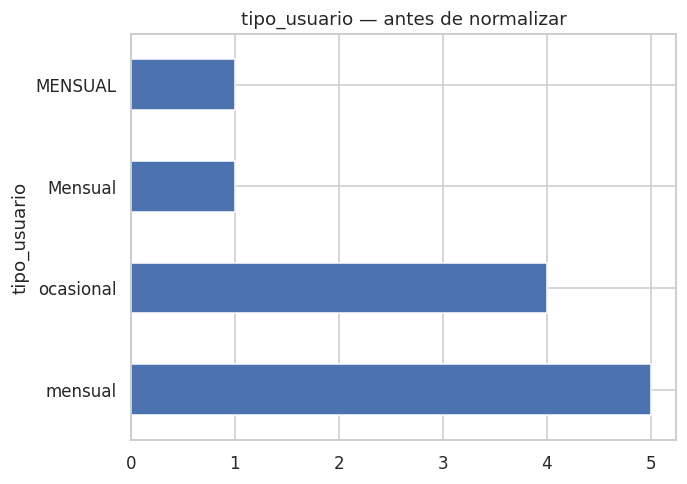

In [8]:
viajes["tipo_usuario"].value_counts().plot(kind="barh")  # la misma receta de arriba, ahora con otra columna
plt.title("tipo_usuario — antes de normalizar")
plt.show()

Normalicen ambas columnas (quitar espacios sobrantes, unificar mayúsculas y minúsculas) y comprueben que ahora cada barra representa una sola categoría real:

In [9]:
# .str abre las herramientas de texto, para aplicarlas a TODA la columna de una sola vez
viajes["estacion_origen"] = viajes["estacion_origen"].str.strip().str.title()
# .strip()  -> quita espacios de más al principio y al final
# .title()  -> deja solo la primera letra de cada palabra en mayúscula

viajes["tipo_usuario"] = viajes["tipo_usuario"].str.strip().str.lower()
# .lower()  -> deja todo el texto en minúscula

viajes["estacion_origen"].value_counts()  # repetimos el conteo para comprobar que ya quedó una sola categoría por estación

,count
estacion_origen,
Chapinero,5
Usaquén,3
Teusaquillo,2
Suba,1


### II.3 · Formato de fecha

Una sola fila trae la fecha en un formato distinto al resto (día/mes/año en vez de año-mes-día). No es un error de contenido, es un error de formato — y por eso `pandas` no reconoció la columna como fecha en la Parte I.

In [10]:
viajes["fecha"] = pd.to_datetime(viajes["fecha"], format="mixed")
# pd.to_datetime() convierte texto en una fecha "de verdad"
# format="mixed" le permite entender más de un formato de fecha dentro de la misma columna

viajes["fecha"].dtype  # confirmamos que ya no diga "object" (texto), sino un tipo de fecha

dtype('<M8[ns]')

### II.4 · Valores nulos

Con solo 11 filas, un mapa de calor de nulos es casi innecesario — se ven a simple vista. Pero con miles de filas es, literalmente, la única forma de ver todos los huecos de una vez. Practíquenlo aquí, a pequeña escala, para que lo reconozcan cuando lo necesiten a gran escala.

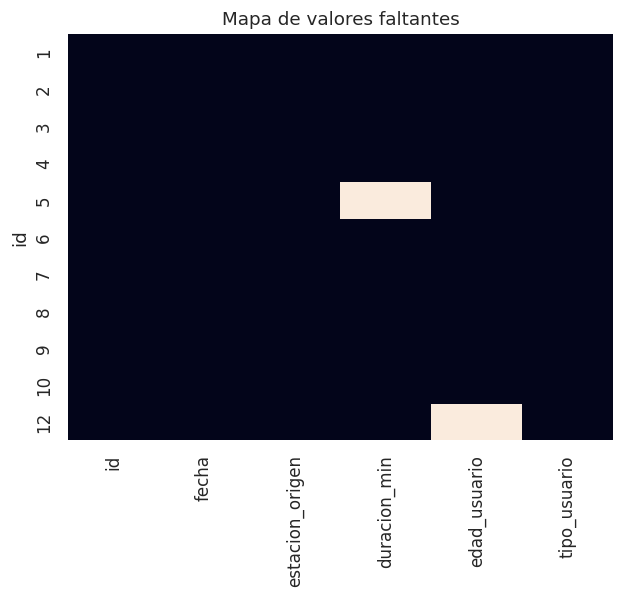

In [11]:
sns.heatmap(viajes.isna(), cbar=False, yticklabels=viajes["id"])
# viajes.isna() convierte la tabla en una tabla de Sí/No: ¿esta celda está vacía?
# sns.heatmap() la dibuja como una cuadrícula de colores, para ver todos los huecos de una sola vez
# cbar=False apaga una barra de color que no hace falta aquí (solo hay dos opciones posibles)
# yticklabels=viajes["id"] muestra el número de viaje real en vez de la posición de la fila

plt.title("Mapa de valores faltantes")
plt.ylabel("id")
plt.show()

En clase vieron tres caminos frente a un dato faltante: **eliminar, imputar o marcar**. Para `duracion_min` y `edad_usuario`, ¿cuál de los tres eligen aquí, y por qué? Con solo dos valores sueltos en 11 filas, piensen qué tan confiable sería inventar un número.

✍️ Mi decisión y mi razón:

*(escriban aquí, en esta misma celda, antes de seguir)*

Yo elegiría marcar los valores faltantes en duracion_min y edad_usuario, ya que solo hay dos datos faltantes en un conjunto muy pequeño de 11 filas. Imputar un valor podría introducir información incorrecta y eliminar filas reduciría aún más la cantidad de datos disponibles, por lo que es más seguro identificarlos y analizarlos posteriormente.

Una opción razonable en un dataset tan pequeño es **marcarlos** como faltantes explícitos, sin inventar un valor. Imputar la media a partir de apenas 10 observaciones sería fabricar una precisión que los datos no tienen. Sigan con esa decisión en mente para la siguiente sección — todavía no toquen estas dos columnas.

### II.5 · Valores imposibles frente a valores atípicos

Esta es la distinción que más cuesta, y la que se presta para una trampa clásica: confundir un dato raro con un dato imposible. Un gráfico de puntos la hace visible de inmediato.

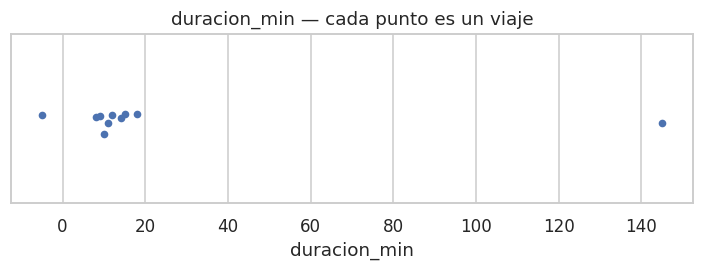

In [12]:
fig, ax = plt.subplots(figsize=(8, 2))  # abrimos un lienzo de 8 de ancho por 2 de alto
sns.stripplot(x=viajes["duracion_min"], ax=ax)  # dibuja cada viaje como un punto individual sobre una sola línea
ax.set_title("duracion_min — cada punto es un viaje")
plt.show()

Hay valores que llaman la atención: uno negativo y uno muy por encima de los demás (145). **Solo uno de los dos es imposible por definición. ¿Cuál, y por qué el otro no lo es?**

Seria el valor de  -5 minutos  ya que es imposible por definición, ya que la duración de un viaje no puede ser negativa. En cambio, 145 minutos es un valor muy alto y atípico, pero no imposible, porque un viaje podría durar ese tiempo en situaciones especiales, por lo que debe revisarse antes de decidir si es un error.

Repitan el ejercicio con `edad_usuario`:

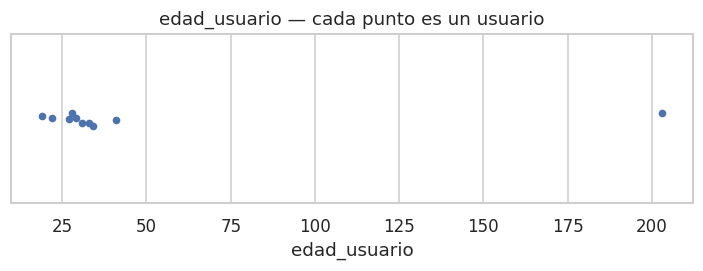

In [13]:
fig, ax = plt.subplots(figsize=(8, 2))
sns.stripplot(x=viajes["edad_usuario"], ax=ax)  # la misma idea de arriba, ahora con la edad de cada usuario
ax.set_title("edad_usuario — cada punto es un usuario")
plt.show()

Una edad de 203 años no admite duda: viola una regla lógica, no una expectativa estadística. Un viaje de 145 minutos, en cambio, es raro pero posible — alguien que olvidó devolver la bicicleta, un recorrido turístico largo. **Borrar un atípico sin investigarlo es una de las formas más comunes de destruir el hallazgo más interesante de un dataset.**



Ahora realiza graficos boxplot para identificar estos mismos errores, recuerda que lo importante por ahora no es el codigo, por lo que puedes investigar como realizarlos, lo importante es que entiendas el grafico y realices una breve descripcion del mismo.

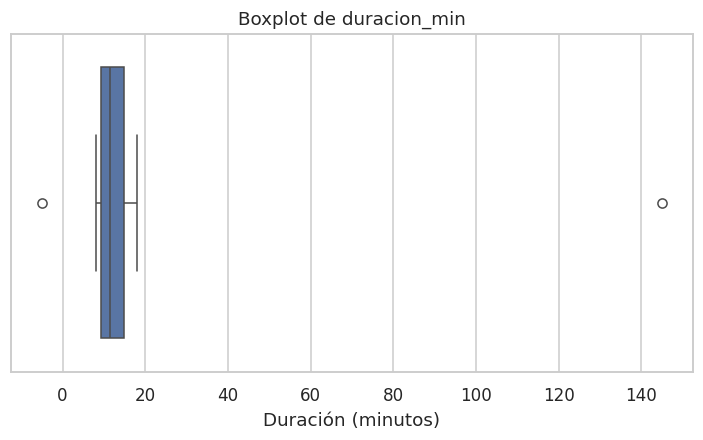

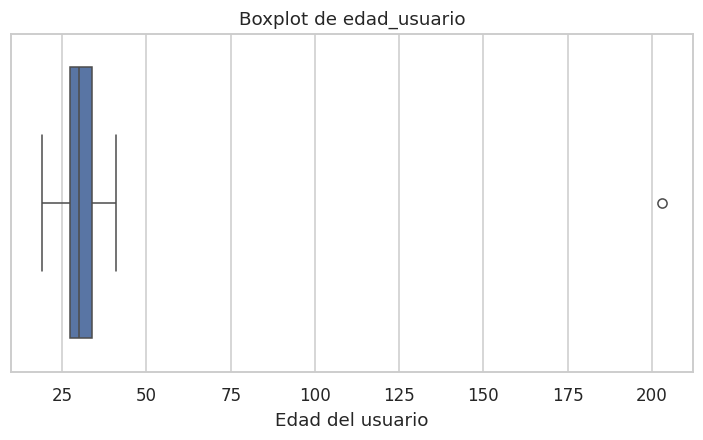

"\nDescripción del Boxplot de edad_usuario:\nEste boxplot de 'edad_usuario' también resalta un valor extremo.\n- El punto a la derecha del bigote, que supera los 200, corresponde a la edad imposible de 203 años que se encontró previamente.\n- El resto de las edades se distribuyen dentro de un rango más esperado, con la mayoría de los datos dentro de la caja central y los bigotes, indicando edades razonables.\n"

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot para duracion_min
plt.figure(figsize=(8, 4))
sns.boxplot(x=viajes["duracion_min"])
plt.title("Boxplot de duracion_min")
plt.xlabel("Duración (minutos)")
plt.show()

"""
Descripción del Boxplot de duracion_min:
Este gráfico de caja y bigotes muestra claramente los valores extremos en la columna 'duracion_min'.
- El punto a la izquierda del bigote, alrededor de -5, representa el valor negativo imposible que se identificó anteriormente.
- El punto a la derecha del bigote, alrededor de 145, es un valor atípico alto que, aunque inusual, no es imposible y debe investigarse.
- La caja central representa el rango intercuartílico (IQR), donde se encuentra el 50% central de los datos. La línea dentro de la caja es la mediana.
"""

# Boxplot para edad_usuario
plt.figure(figsize=(8, 4))
sns.boxplot(x=viajes["edad_usuario"])
plt.title("Boxplot de edad_usuario")
plt.xlabel("Edad del usuario")
plt.show()

"""
Descripción del Boxplot de edad_usuario:
Este boxplot de 'edad_usuario' también resalta un valor extremo.
- El punto a la derecha del bigote, que supera los 200, corresponde a la edad imposible de 203 años que se encontró previamente.
- El resto de las edades se distribuyen dentro de un rango más esperado, con la mayoría de los datos dentro de la caja central y los bigotes, indicando edades razonables.
"""

Apliquen el tratamiento: marquen como faltantes los valores imposibles y conserven el atípico.

In [15]:
# .loc[condición, "columna"] = valor   →   "en las filas donde se cumple esto, cambia SOLO esta columna"
viajes.loc[viajes["duracion_min"] < 0, "duracion_min"] = np.nan    # una duración negativa no puede existir
viajes.loc[viajes["edad_usuario"] > 100, "edad_usuario"] = np.nan  # tampoco una edad mayor a 100 años
# El valor de 145 minutos NO se toca: es un dato raro pero posible, no imposible.

viajes

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
0,1,2025-03-01,Chapinero,12.0,28.0,mensual
1,2,2025-03-01,Chapinero,8.0,34.0,ocasional
2,3,2025-03-02,Usaquén,15.0,22.0,mensual
3,4,2025-03-02,Chapinero,NaN,41.0,mensual
4,5,2025-03-03,Teusaquillo,NaN,29.0,ocasional
5,6,2025-03-03,Usaquén,145.0,31.0,mensual
6,7,2025-03-03,Chapinero,11.0,19.0,ocasional
7,8,2025-03-04,Teusaquillo,9.0,NaN,mensual
8,9,2025-03-04,Usaquén,14.0,27.0,mensual
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional


### II.6 · Reporte de impacto

Toda limpieza de datos debería terminar con una pregunta obligatoria: ¿qué porcentaje de los registros quedó afectado por mis propias decisiones? Aquí no la contesten a mano — calcúlenla con código:

In [16]:
filas_afectadas = viajes.isna().any(axis=1).sum()
# .isna()        -> tabla de Sí/No: ¿está vacío?
# .any(axis=1)   -> revisa cada FILA: ¿hay al menos un Sí en ella?
# .sum()         -> cuenta cuántas filas tuvieron al menos un Sí (en Python, Sí=1 y No=0)

print(f"{filas_afectadas} de {len(viajes)} filas quedaron con al menos un valor marcado como faltante")
print(f"eso es {filas_afectadas / len(viajes):.0%} del total")  # :.0% convierte el número decimal en porcentaje

4 de 11 filas quedaron con al menos un valor marcado como faltante
eso es 36% del total


🎯 Guarden esa cifra. Un analista que no reporta cuánto perdió en la limpieza está ocultando, sin querer, cuánto hay que confiar en lo que viene después.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 3 &nbsp;·&nbsp; 📈 A ESCALA REAL</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">De 12 filas a mil doscientas</h2>
</div>

Doce filas se pueden revisar a ojo, columna por columna, como acaban de hacerlo. Mil doscientas ya no. A partir de aquí trabajamos con una versión a escala real del mismo fenómeno — viajes de bicicleta compartida durante un mes completo —, construida para que se comporte como datos reales: con sus propios patrones y su propia suciedad, no perfecta.

In [17]:
rng = np.random.default_rng(7)  # una "máquina" de números al azar; el 7 es la semilla, para que siempre salga igual
n = 1200                        # cuántos viajes vamos a fabricar

estaciones = ["Chapinero", "Usaquén", "Teusaquillo", "Suba", "Kennedy"]
tipo_usuario = rng.choice(["mensual", "ocasional"], size=n, p=[0.62, 0.38])  # elige al azar, pero 62% mensual y 38% ocasional
es_mensual = tipo_usuario == "mensual"  # una lista de Sí/No que vamos a reutilizar varias veces más abajo

fecha = pd.Timestamp("2025-03-01") + pd.to_timedelta(rng.integers(0, 31, n), unit="D")  # una fecha al azar dentro de marzo
estacion = rng.choice(estaciones, size=n, p=[0.28, 0.22, 0.18, 0.17, 0.15])              # elige estación, cada una con su propia probabilidad

pico_commute = rng.choice([7, 18], size=n)  # cada viaje "apunta" a la hora pico de la mañana o de la tarde
hora = np.where(
    es_mensual,
    np.clip(rng.normal(pico_commute, 1.2, n).round(), 5, 22),  # si es mensual: una hora cercana a su pico, redondeada
    rng.integers(8, 21, n),                                     # si es ocasional: cualquier hora entre 8am y 8pm, sin patrón
).astype(int)

duracion = rng.normal(np.where(es_mensual, 13, 22),
                       np.where(es_mensual, 4, 12), n).clip(2, None).round(1)
# los usuarios mensuales viajan en promedio 13 min (poca variación); los ocasionales, 22 min (mucha más variación)

edad = np.clip(
    rng.normal(np.where(es_mensual, 31, 26), np.where(es_mensual, 6, 9), n),
    15, 75
).round().astype(int)
# la misma idea para la edad: 31 años en promedio si es mensual, 26 si es ocasional

viajes_marzo = pd.DataFrame({
    "fecha": fecha, "hora": hora, "estacion": estacion,
    "duracion_min": duracion, "edad_usuario": edad, "tipo_usuario": tipo_usuario,
})  # aquí juntamos todas las columnas sueltas en una sola tabla

# Como en cualquier dataset real: nadie garantiza que llegue impecable.
ruido = rng.choice(n, size=18, replace=False)  # elegimos 18 filas al azar, sin repetir ninguna
viajes_marzo.loc[ruido[:6], "duracion_min"] = -rng.integers(1, 10, 6)      # a 6 de ellas, les dañamos la duración (negativa)
viajes_marzo.loc[ruido[6:12], "edad_usuario"] = rng.integers(100, 140, 6)  # a otras 6, una edad imposible
viajes_marzo.loc[ruido[12:], "duracion_min"] = np.nan                     # y a las últimas 6, un dato faltante

print(viajes_marzo.shape)
viajes_marzo.sample(8, random_state=1)  # .sample() muestra 8 filas elegidas al azar, no solo las primeras

(1200, 6)


,fecha,hora,estacion,duracion_min,edad_usuario,tipo_usuario
636,2025-03-09,5,Usaquén,14.7,30,mensual
683,2025-03-02,19,Kennedy,37.9,34,ocasional
1033,2025-03-15,16,Kennedy,16.9,25,mensual
190,2025-03-01,6,Chapinero,13.2,34,mensual
1083,2025-03-19,18,Suba,8.6,41,mensual
283,2025-03-19,5,Kennedy,10.9,30,mensual
817,2025-03-14,16,Teusaquillo,8.6,45,mensual
314,2025-03-08,8,Suba,11.2,34,mensual


Antes de explorar nada, repitan el mismo chequeo de la Parte II, pero ya no fila por fila: con un resumen y un gráfico.

In [18]:
viajes_marzo[["duracion_min", "edad_usuario"]].describe()
# .describe() calcula de una sola vez: cuántos datos hay, el promedio, cuánto varían, el mínimo y el máximo

,duracion_min,edad_usuario
count,1194.000000,1200.000000
mean,15.939196,29.290000
std,8.589985,9.643741
min,-7.000000,15.000000
25%,10.725000,24.000000
50%,14.250000,29.000000
75%,19.000000,34.000000
max,52.600000,136.000000


✍️ Miren el mínimo y el máximo de cada columna en la tabla de arriba: ¿son compatibles con la realidad de un viaje en bicicleta? Con esa respuesta, filtren lo imposible antes de seguir:

No, ya que no todos los valores son compatibles con la realidad. El mínimo de duracion_min (-7) es imposible, ya que un viaje no puede tener una duración negativa, y el máximo de edad_usuario (136) también es poco realista para un usuario. Por ello, antes de continuar, se deben filtrar o eliminar esos registros con valores imposibles para evitar que afecten el análisis.

In [19]:
antes = len(viajes_marzo)  # guardamos cuántas filas había, para comparar después

viajes_marzo = viajes_marzo[
    (viajes_marzo["duracion_min"].isna() | (viajes_marzo["duracion_min"] > 0)) &  # duración vacía, O positiva
    (viajes_marzo["edad_usuario"] <= 100)                                          # Y, además, edad de máximo 100 años
].copy()
# | significa "o", & significa "y" — aquí combinamos varias condiciones para quedarnos solo con las filas válidas

print(f"{antes - len(viajes_marzo)} filas descartadas por contener un valor imposible")

viajes_marzo["duracion_min"] = viajes_marzo["duracion_min"].fillna(viajes_marzo["duracion_min"].median())
# .fillna() rellena los vacíos que quedan con la mediana de la propia columna
viajes_marzo.shape

12 filas descartadas por contener un valor imposible


(1188, 6)

Noten la diferencia de criterio con la Parte II: allá **marcaron** los valores imposibles porque perder una sola fila de 11 sí importaba. Aquí los **descartamos** directamente: miren arriba cuántas filas fueron — es una fracción mínima de 1200 y no distorsiona nada. Y a los pocos nulos que quedaron en `duracion_min` los imputamos con la mediana, algo que con solo 11 filas hubiera sido fabricar precisión de la nada.

🎯 **La estrategia frente a un dato faltante o imposible depende de la escala, no solo de qué representa el dato.** Es la misma regla de la Parte II, aplicada con otro criterio porque el tamaño cambió.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 4 &nbsp;·&nbsp; 🔬 ANÁLISIS EXPLORATORIO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Las cuatro preguntas del EDA</h2>
</div>

En clase vieron que el EDA responde cuatro preguntas: distribución, atípicos, relaciones y grupos. Vamos una por una. **Estos gráficos son deliberadamente rápidos y sin estética: es el modo exploratorio, no el comunicativo.** Nadie más los va a ver.

### IV.1 · Distribución

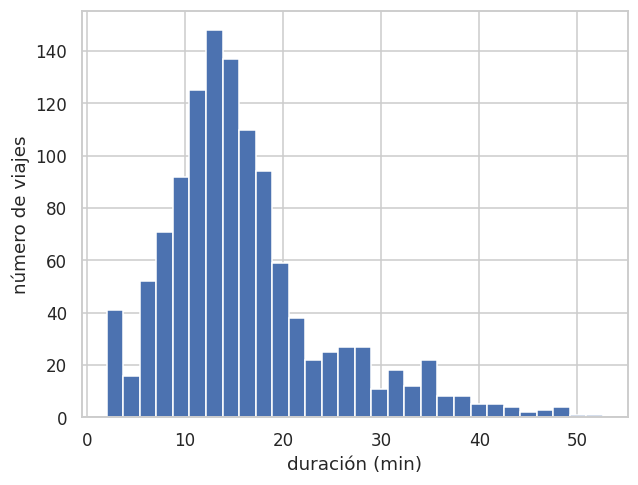

In [20]:
viajes_marzo["duracion_min"].hist(bins=30)  # bins=30 reparte los valores en 30 "cajitas" para ver la forma completa
plt.xlabel("duración (min)")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿La forma es simétrica o está inclinada hacia un lado? ¿Ven una sola concentración de valores o más de una? Anoten una hipótesis de por qué podría ser así, antes de seguir leyendo.

ya que la distribución no es simétrica, sino que está inclinada hacia la derecha, ya que la mayoría de los viajes se concentran entre 10 y 18 minutos, mientras que hay una cola de viajes más largos. Se observa una concentración principal de valores y algunos viajes de mayor duración, lo que podría deberse a que la mayoría de los usuarios realizan recorridos cortos y solo unos pocos hacen trayectos más largos.

### IV.2 · Atípicos

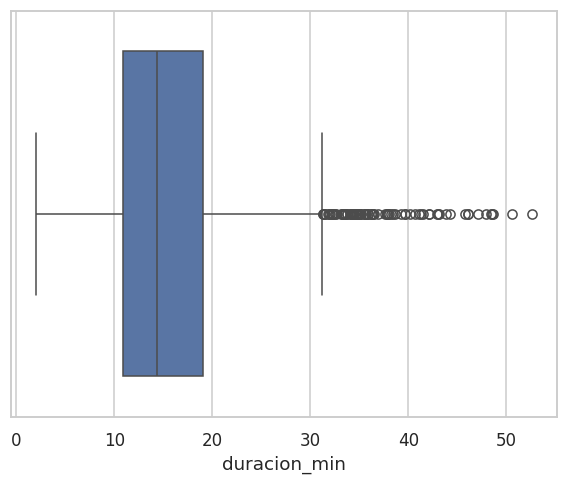

In [21]:
sns.boxplot(data=viajes_marzo, x="duracion_min")
# la "caja" muestra el 50% central de los datos; los puntos sueltos son los que el boxplot marca como atípicos
plt.show()

✍️ El boxplot marca varios puntos como atípicos. Con lo que trabajaron en la Parte II: ¿son necesariamente errores? ¿Qué preguntarían antes de decidir qué hacer con ellos?

No, ya que los valores atípicos no son necesariamente errores; simplemente son datos que se alejan del resto de las observaciones. Antes de decidir eliminarlos, habría que preguntar si esos viajes largos son reales, si corresponden a recorridos excepcionales o si se deben a errores en el registro de los datos.

### IV.3 · Relaciones

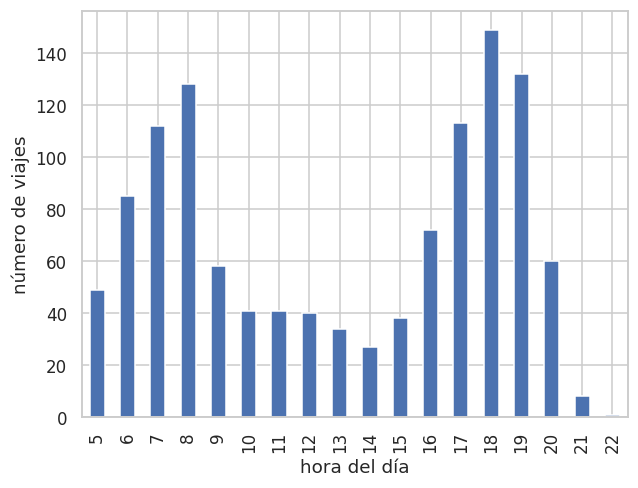

In [22]:
viajes_marzo["hora"].value_counts().sort_index().plot(kind="bar")
# .sort_index() ordena por la hora (0,1,2...23) en vez de por cuál se repite más
plt.xlabel("hora del día")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿En qué horas se concentran los viajes? ¿Hay un solo momento de mayor actividad o más de uno? ¿A qué costumbre de una ciudad podría corresponder ese patrón?

En los viajes se concentran en las dos franjas horarias principales: la mañana (de 6:00 a 8:00, con un pico a las 8:00) y la tarde/noche (de 17:00 a 19:00, alcanzando el punto máximo absoluto a las 18:00), por lo tanto no existe un solo momento de mayor actividad sino un patrón bimodal. Este comportamiento corresponde a la movilidad pendular urbana habitual de las ciudades, caracterizada por las "horas pico" asociadas a la entrada y salida de las jornadas laborales y académicas cotidianas.

### IV.4 · Grupos

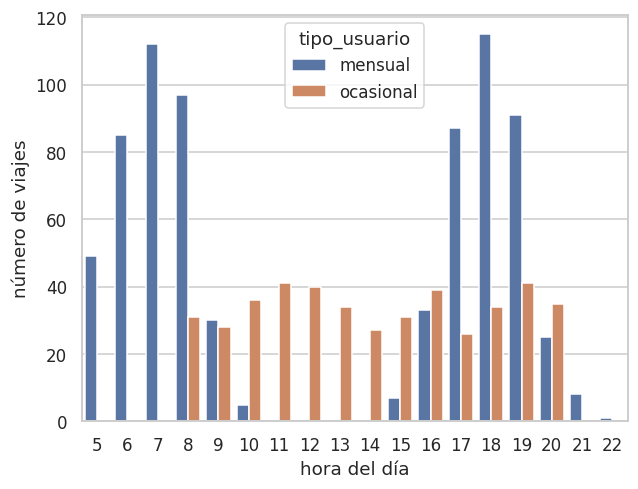

In [23]:
sns.countplot(data=viajes_marzo, x="hora", hue="tipo_usuario")
# hue="tipo_usuario" dibuja una barra por hora Y por tipo de usuario, para comparar los dos grupos en el mismo gráfico
plt.xlabel("hora del día")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿El patrón de horas es igual para los dos tipos de usuario? Si no lo es, ¿qué explicación del mundo real (no una explicación estadística) se les ocurre para la diferencia?

En el patrón de horas no es igual para ambos tipos de usuario, ya que los usuarios mensuales presentan picos muy marcados en las horas pico de la mañana (7:00–8:00) y de la tarde (17:00–18:00), mientras que los usuarios ocasionales muestran una distribución continua e uniforme durante las horas centrales del día (10:00 a 20:00). En el mundo real, esta diferencia responde al propósito de viaje de cada grupo: los suscriptores mensuales utilizan el servicio para su transporte cotidiano y obligatorio hacia el trabajo o lugar de estudio bajo horarios fijos, mientras que los usuarios ocasionales son principalmente turistas, visitantes o residentes realizando compras, trámites o actividades recreativas con horarios mucho más flexibles.

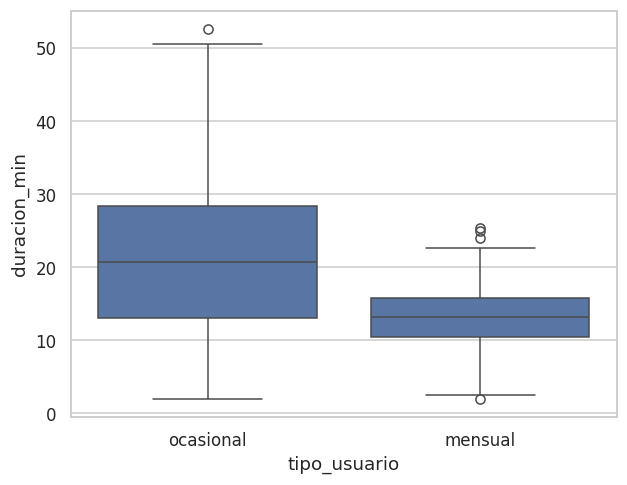

In [24]:
sns.boxplot(data=viajes_marzo, x="tipo_usuario", y="duracion_min")
# con una columna de categorías en x y una numérica en y, seaborn dibuja automáticamente una caja por categoría
plt.show()

✍️ ¿Qué grupo hace viajes más largos? ¿Cuál de los dos es más variable — la caja y los bigotes más anchos o más angostos? Si tuvieran que resumir la duración típica de cada grupo con un solo número, ¿usarían la media o la mediana? Justifiquen la respuesta con lo que vieron en IV.1 y IV.2, no solo con la definición de cada estadístico.

Con las cuatro preguntas respondidas, noten algo: en un análisis exploratorio real ustedes producirían docenas de gráficos como estos y descartarían la mayoría. Aquí solo vieron cinco, a propósito, para que el ejercicio no se les vuelva eterno — pero la lógica de "muchos, rápidos, desechables" es la misma que van a aplicar en su proyecto.


En el grupo de usuarios ocasionales hace trayectos más largos y presenta una mayor variabilidad en la duración de sus viajes, en  lo cual se evidencia en una caja y unos bigotes visiblemente más altos y anchos en el diagrama, extendiéndose desde trayectos cortos hasta de más de 50 minutos. En contraste, los usuarios mensuales exhiben tiempos de recorrido mucho más cortos y consistentes, concentrados principalmente entre los 10 y 16 minutos. Para resumir la duración típica de cada grupo con un solo número, conviene usar la mediana (~21 minutos para ocasionales y ~13 minutos para mensuales), dado que ambas distribuciones sufren de asimetría y valores atípicos (como los valores extremos observados en la parte superior e inferior); la mediana es una medida robusta que no se ve sesgada por estos extremos, a diferencia de la media, ofreciendo una representación más fiel de la tendencia central observada en la distribución de viajes.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 5 &nbsp;·&nbsp; 🎯 DE EXPLORAR A DECIDIR</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Un hallazgo, un gráfico</h2>
</div>

En la clase de visualización exploratoria y comunicativa vieron los cinco pasos para convertir un gráfico exploratorio en uno comunicativo. Apliquenlos a **uno solo** de los hallazgos de la Parte IV — por ejemplo, la diferencia de duración entre tipos de usuario.

✍️ **Paso 1 — escriban la conclusión.** Antes de tocar el gráfico de abajo, escriban en una frase completa (sujeto, verbo, magnitud) qué quieren que alguien entienda. Esa frase va a ser el título.

*(Los usuarios ocasionales realizan viajes promedio de 21 minutos, superando por 8 minutos a los mensuales )*


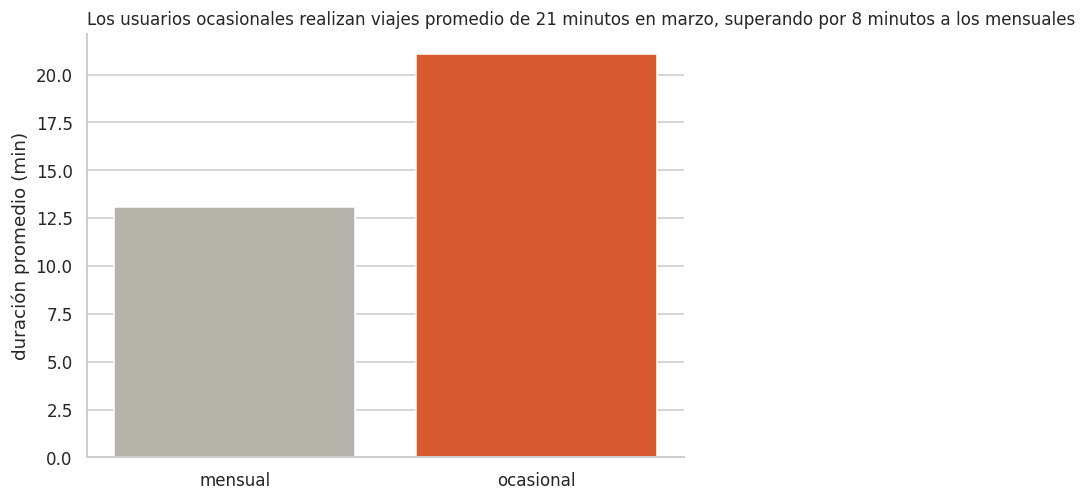

In [25]:
promedio = viajes_marzo.groupby("tipo_usuario")["duracion_min"].mean()

colores = ["#B4B2A9", "#B4B2A9"]
colores[promedio.values.argmax()] = "#D85A30"

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(promedio.index, promedio.values, color=colores)
ax.set_title("Los usuarios ocasionales realizan viajes promedio de 21 minutos en marzo, superando por 8 minutos a los mensuales", loc="left", fontsize=11)
ax.set_ylabel("duración promedio (min)")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="x", visible=False)
plt.show()

✍️ Reemplacen el título del gráfico por la frase que escribieron en el Paso 1 y vuelvan a ejecutar la celda. Después, pásenle este checklist:

- [x] ¿El título dice la conclusión, o solo nombra la variable?: Sí, ya que mi título  comunica directamente el hallazgo principal: "Los usuarios ocasionales realizan viajes promedio de 21 minutos en marzo, superando por 8 minutos a los mensuales." Esta modificación se realizó directamente en la celda `--ECYFDazUQm` en la línea `ax.set_title(...)`.

- [x] ¿Se entiende sin que ustedes estén al lado explicándolo?: Sí,ya que el gráfico es claro, conciso y el mensaje es inmediatamente perceptible. La combinación de un título informativo, colores contrastantes y la eliminación de elementos superfluos contribuye a su autoexplicación.

- [x] ¿Hay algo que puedan quitar sin perder el mensaje?: Sí, se han eliminado elementos superfluos como los bordes 'top' y 'right' del gráfico, y la cuadrícula en el eje X, para mantener la atención en los datos esenciales. Esto se hizo en la celda `--ECYFDazUQm` con las líneas `ax.spines[lado].set_visible(False)` y `ax.grid(axis="x", visible=False)`.

- [x] ¿El color destaca lo importante, o solo decora?: Sí, ya que el color se utiliza intencionadamente para resaltar la categoría de usuarios ocasionales, que es el punto clave del hallazgo, mientras que el otro grupo se mantiene en un color neutro. La lógica para los colores está definida en la celda `--ECYFDazUQm` con `colores[promedio.values.argmax()] = "#D85A30"`.

- [x] ¿Están las unidades y el periodo de los datos?: Sí,ya que el título especifica claramente las unidades ("minutos") y el periodo de los datos ("en marzo"). Esto fue añadido en la celda `--ECYFDazUQm` como parte del título `ax.set_title(...)`.

- [x] ¿La comparación es directa, o hay que hacer cuentas para verla?: Sí, ya que la comparación entre los dos tipos de usuario es directa y visualmente evidente gracias a las barras adyacentes y la cuantificación en el título.

- [x] ¿Alguien ajeno al proyecto lo entendería en cinco segundos?: Sí,ya que el diseño del gráfico y el título están pensados para que el mensaje sea captado rápidamente por cualquier persona, incluso sin contexto previo.

💡 Si alguna respuesta es "no", vuelvan a la celda de código y ajústenla. Este gráfico, y no los de la Parte IV, es el que podría ir en una presentación.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 6 &nbsp;·&nbsp; 🚀 SU TURNO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Ahora, con su propio dataset</h2>
</div>

Todo lo anterior fue un ensayo con un caso conocido. Lo que sigue es la plantilla para repetir el mismo recorrido con el dataset de **su proyecto**, camino al Hito 1: pregunta definida, dataset elegido y limpio, análisis exploratorio y primeras visualizaciones.

In [26]:
# Si están en Colab y quieren subir su archivo desde el computador,
# descomenten estas dos líneas y ejecuten la celda:

# from google.colab import files
# subido = files.upload()

df = None  # <-- reemplacen esta línea por: df = pd.read_csv("su_archivo.csv")

Con `df` cargado, recorran las mismas preguntas de las Partes I a V, en el mismo orden. No copien los gráficos de este cuaderno tal cual: cada dataset tiene su propia suciedad y su propio patrón, y la gracia de este recorrido es que ustedes decidan qué preguntar, no que reproduzcan un ejemplo.

In [27]:
# 1. Primera mirada (Parte I)
# df.shape
# df.dtypes
# df.head()

# 2. Duplicados (Parte II.1)
# df[df.duplicated(keep=False)]

# 3. Categorías inconsistentes (Parte II.2): value_counts() de cada columna de texto

# 4. Formato de fecha, si aplica (Parte II.3)

# 5. Valores nulos (Parte II.4): df.isna().sum()  o  sns.heatmap(df.isna())

# 6. Imposibles frente a atípicos (Parte II.5): histograma o boxplot de cada columna numérica

# 7. Reporte de impacto (Parte II.6): % de filas afectadas por sus decisiones

# 8. Las cuatro preguntas del EDA (Parte IV): distribución, atípicos, relaciones, grupos

# 9. Un solo gráfico comunicativo (Parte V), con título que afirme el hallazgo,
#    evaluado con el checklist de siete preguntas

<div style="background:#022F35;padding:28px 32px;border-radius:16px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">CIERRE</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Lo que ya saben hacer</h2>
</div>

Recorrieron tres etapas del ciclo de vida de los datos —recolección, limpieza y análisis exploratorio— con el mismo criterio con el que las vieron en clase, primero a mano en 11 filas y después a escala en 1200. La herramienta cambió; el criterio para decidir qué es un problema real, qué es un dato imposible, qué es un atípico que vale la pena investigar y qué merece un gráfico propio, no cambió.

Antes de cerrar, revisen esta lista sobre lo que acaban de hacer:

- [x] Puedo explicar la diferencia entre un valor imposible y un valor atípico con un ejemplo propio, no solo con el de las bicicletas.
- [x] Sé nombrar las tres estrategias frente a un dato faltante y cuándo usar cada una.
- [x] Entiendo por qué la estrategia de limpieza puede cambiar según el tamaño del dataset.
- [x] Puedo distinguir, en cualquier gráfico que me muestren, si fue hecho para explorar o para comunicar.
- [x] Sé nombrar las cuatro preguntas del análisis exploratorio sin mirar este cuaderno.
- [x] Mi gráfico final tiene un título que afirma una conclusión, no que nombra una variable.
- [x] Puedo decir cuántos de mis registros quedaron afectados por mis propias decisiones de limpieza.

Esto es exactamente lo que van a entregar en el Hito 1 del proyecto de semestre, con su propio dataset en vez del de las bicicletas: la pregunta, los datos ya limpios, el análisis exploratorio y las primeras visualizaciones. Las próximas clases retoman estos mismos gráficos para trabajar percepción visual, principios de diseño (Tufte, Few) y color — es decir, cómo convertir mejor lo exploratorio en comunicativo, no un tema nuevo.

### Referencias usadas en este cuaderno

- Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10).
- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician, 27*(1), 17–21.
- Knaflic, C. N. (2017). *Storytelling con datos: visualización de datos para profesionales*. Anaya Multimedia.
- Kusleika, D. (2021). *Data Visualization with Excel Dashboards and Reports* (cap. 4). Wiley.